 # Data Driven Model: Predicting London Background Ozone from Weather Data

 40% of the overall grade for Artificial Intelligence model

Emmanuella Nyamekye

## Stage 1: Describe the Data

### Dataset 1: London Weather Data
**Source:** [Kaggle - London Weather Data](https://www.kaggle.com/datasets/emmanuelfwerr/london-weather-data)

Daily weather observations recorded in London. Contains meteorological measurements including temperature, sunshine, radiation, precipitation and pressure.

**Columns:**
- `date` date of recording (YYYYMMDD format)
- `cloud_cover` cloud cover in oktas (0-9)
- `sunshine` hours of sunshine
- `global_radiation` global radiation in W/m²
- `max_temp` maximum temperature in °C
- `mean_temp` mean temperature in °C
- `min_temp` minimum temperature in °C
- `precipitation` precipitation in mm
- `pressure` air pressure in hPa
- `snow_depth` snow depth in cm

---

### Dataset 2: London Air Quality Data
**Source:** [Kaggle - London Air Quality](https://www.kaggle.com/datasets/emmanuelfwerr/london-aqi-data)

Daily air quality measurements recorded across London monitoring stations. Contains pollutant concentrations for both roadside and background monitoring sites.

**Key Column (Target):**
- `London Mean Background Ozone (ug/m3)` - our prediction target

**Other columns include:** Nitric Oxide, Nitrogen Dioxide, PM10, PM2.5, Sulphur Dioxide.

---

### Linking the Datasets
Both datasets share a `date` column. They will be merged on `date` so that each row contains both the weather conditions and the air quality measurements for the same day in London.

In [ ]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns                                   # Creates the heatmap chart
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression       # Draws a straight line through the data to make predictions
from sklearn.tree import DecisionTreeRegressor          # Predicts numbers using a decision tree
from sklearn.ensemble import RandomForestRegressor      # Ensemble of many decision trees
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
# Load the datasets
weather_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Artificial Intelligence/Projects/Predict_Air Quality_from_Weather/london_weather.csv')
air_df     = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Artificial Intelligence/Projects/Predict_Air Quality_from_Weather/london_air_quality.csv')

print('Weather dataset shape:', weather_df.shape)
print('Air quality dataset shape:', air_df.shape)

Weather dataset shape: (15341, 10)
Air quality dataset shape: (3168, 16)


In [ ]:
# Preview the weather dataset
weather_df.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


In [ ]:
# Preview the air quality dataset
air_df.head()

,Date,GMT,London Mean Roadside Nitric Oxide (ug/m3),London Mean Roadside Nitrogen Dioxide (ug/m3),London Mean Roadside Oxides of Nitrogen (ug/m3),London Mean Roadside Ozone (ug/m3),London Mean Roadside PM10 Particulate (ug/m3),London Mean Roadside PM2.5 Particulate (ug/m3),London Mean Roadside Sulphur Dioxide (ug/m3),London Mean Background Nitric Oxide (ug/m3),London Mean Background Nitrogen Dioxide (ug/m3),London Mean Background Oxides of Nitrogen (ug/m3),London Mean Background Ozone (ug/m3),London Mean Background PM10 Particulate (ug/m3),London Mean Background PM2.5 Particulate (ug/m3),London Mean Background Sulphur Dioxide (ug/m3)
0,01/01/2008,00:00,NaN,42.258065,NaN,32.645161,22.967742,15.516129,3.354839,NaN,34.193548,NaN,41.774194,19.161290,NaN,3.129032
1,01/01/2008,01:00,NaN,33.774194,NaN,35.290323,21.161290,13.548387,2.612903,NaN,29.000000,NaN,45.290323,18.903226,NaN,3.064516
2,01/01/2008,02:00,NaN,28.838710,NaN,43.161290,19.580645,12.677419,2.129032,NaN,25.354839,NaN,46.645161,17.677419,NaN,3.290323
3,01/01/2008,03:00,NaN,27.322581,NaN,42.387097,18.322581,11.870968,1.967742,NaN,23.387097,NaN,46.645161,16.387097,NaN,3.322581
4,01/01/2008,04:00,NaN,29.387097,NaN,40.129032,18.096774,11.967742,2.193548,NaN,24.193548,NaN,45.225806,16.000000,NaN,2.774194


In [ ]:
# Rename 'Date' to 'date' in air_df so both match for the merge
air_df = air_df.rename(columns={'Date': 'date'})

In [ ]:
# Summary statistics for weather data
weather_df.describe()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
count,1.534100e+04,15322.000000,15341.000000,15322.000000,15335.000000,15305.000000,15339.000000,15335.000000,15337.000000,13900.000000
mean,1.999567e+07,5.268242,4.350238,118.756951,15.388777,11.475511,7.559867,1.668634,101536.605594,0.037986
std,1.212176e+05,2.070072,4.028339,88.898272,6.554754,5.729709,5.326756,3.738540,1049.722604,0.545633
min,1.979010e+07,0.000000,0.000000,8.000000,-6.200000,-7.600000,-11.800000,0.000000,95960.000000,0.000000
25%,1.989070e+07,4.000000,0.500000,41.000000,10.500000,7.000000,3.500000,0.000000,100920.000000,0.000000
50%,2.000010e+07,6.000000,3.500000,95.000000,15.000000,11.400000,7.800000,0.000000,101620.000000,0.000000
75%,2.010070e+07,7.000000,7.200000,186.000000,20.300000,16.000000,11.800000,1.600000,102240.000000,0.000000
max,2.020123e+07,9.000000,16.000000,402.000000,37.900000,29.000000,22.300000,61.800000,104820.000000,22.000000


In [ ]:
# Summary statistics for air quality data
air_df.describe()

,London Mean Roadside Nitric Oxide (ug/m3),London Mean Roadside Nitrogen Dioxide (ug/m3),London Mean Roadside Oxides of Nitrogen (ug/m3),London Mean Roadside Ozone (ug/m3),London Mean Roadside PM10 Particulate (ug/m3),London Mean Roadside PM2.5 Particulate (ug/m3),London Mean Roadside Sulphur Dioxide (ug/m3),London Mean Background Nitric Oxide (ug/m3),London Mean Background Nitrogen Dioxide (ug/m3),London Mean Background Oxides of Nitrogen (ug/m3),London Mean Background Ozone (ug/m3),London Mean Background PM10 Particulate (ug/m3),London Mean Background PM2.5 Particulate (ug/m3),London Mean Background Sulphur Dioxide (ug/m3)
count,2592.000000,3168.000000,2592.000000,3168.000000,3168.000000,3168.000000,3168.000000,2592.000000,3168.000000,2592.000000,3168.000000,3168.000000,3072.000000,3168.000000
mean,78.339254,55.757291,139.490022,27.173816,25.122292,15.715066,3.262949,22.122995,34.864790,56.383385,36.894533,19.272478,13.292989,3.362393
std,41.165511,13.456008,51.788558,10.554851,6.111801,5.187532,1.661654,17.258042,10.838895,26.522083,15.018422,4.972061,4.755642,1.112722
min,9.163333,20.996774,37.803571,6.410000,11.812903,5.907143,-2.383871,1.419355,11.529032,13.461290,8.732258,10.229032,5.612903,0.730000
25%,46.527419,47.099194,101.602419,19.391935,20.938871,12.052903,2.231607,9.690323,26.235657,36.524355,25.723848,15.903226,9.873978,2.596774
50%,72.861774,55.756667,136.022581,25.941935,24.286828,14.334167,3.134409,16.737385,33.098387,49.200952,34.708226,18.133333,12.045968,3.319677
75%,103.343437,64.977500,171.520403,33.792742,28.320161,18.129274,4.241379,29.292742,41.936434,69.950893,46.143980,21.484570,15.625000,4.032258
max,257.264516,95.551724,336.270968,66.290323,52.093548,36.523333,10.867742,120.364516,74.310345,193.654839,96.051613,43.438710,33.366667,9.034483


In [ ]:
# Print all column names in the air quality dataset
print(air_df.columns.tolist())

['date', 'GMT', 'London Mean Roadside Nitric Oxide (ug/m3)', 'London Mean Roadside Nitrogen Dioxide (ug/m3)', 'London Mean Roadside Oxides of Nitrogen (ug/m3)', 'London Mean Roadside Ozone (ug/m3)', 'London Mean Roadside PM10 Particulate (ug/m3)', 'London Mean Roadside PM2.5 Particulate (ug/m3)', 'London Mean Roadside Sulphur Dioxide (ug/m3)', 'London Mean Background Nitric Oxide (ug/m3)', 'London Mean Background Nitrogen Dioxide (ug/m3)', 'London Mean Background Oxides of Nitrogen (ug/m3)', 'London Mean Background Ozone (ug/m3)', 'London Mean Background PM10 Particulate (ug/m3)', 'London Mean Background PM2.5 Particulate (ug/m3)', 'London Mean Background Sulphur Dioxide (ug/m3)']


In [ ]:
# Print all column names in the weather dataset
print(weather_df.columns.tolist())

['date', 'cloud_cover', 'sunshine', 'global_radiation', 'max_temp', 'mean_temp', 'min_temp', 'precipitation', 'pressure', 'snow_depth']


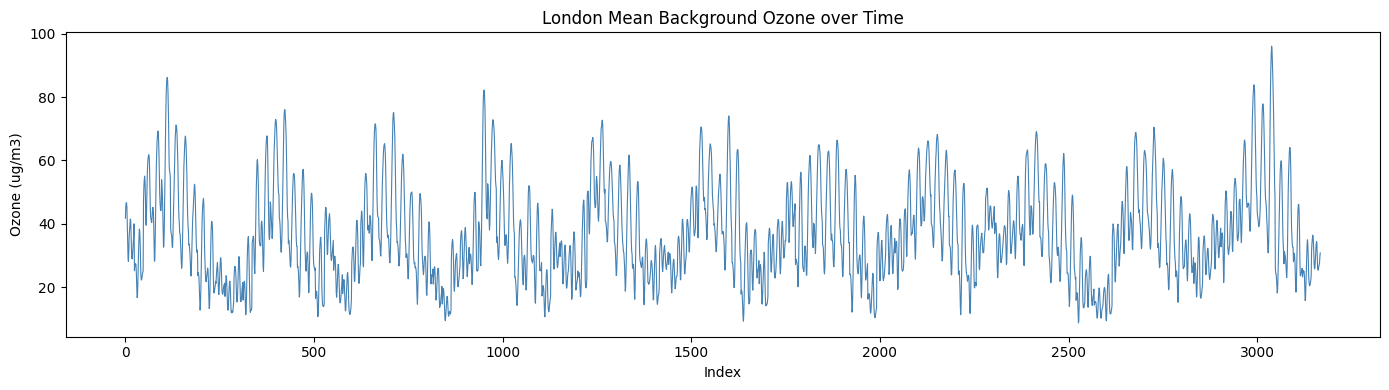

In [ ]:
# Plot the target variable over time to understand its distribution
plt.figure(figsize=(14, 4))
plt.plot(air_df['London Mean Background Ozone (ug/m3)'], color='steelblue', linewidth=0.8)
plt.title('London Mean Background Ozone over Time')
plt.xlabel('Index')
plt.ylabel('Ozone (ug/m3)')
plt.tight_layout()
plt.show()

## Stage 2: Justification for the Prediction Target

The target variable chosen is **London Mean Background Ozone (ug/m3)**.

Background ozone measured away from direct traffic sources is strongly influenced by meteorological conditions. Ozone forms through chemical reactions driven by sunlight, temperature and atmospheric pressure. On hot, sunny, high-pressure days ozone levels typically rise, while rain and cloud cover tend to suppress it.

This makes background ozone an ideal target for prediction from weather features because:
- It has a well-understood relationship with weather variables (especially sunshine, temperature and pressure)
- It is a continuous numerical value making this a **regression** problem
- Both datasets share a `date` column allowing a merge
- Predicting ozone has real public health value as high ozone levels cause respiratory problems

Following the [scikit-learn estimator map](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html): since we are predicting a **continuous quantity** with **labelled training data**, this is a **Regression** task.

## Stage 3: Cleaning and Linking the Data

In [ ]:
# Check missing values in weather data BEFORE any cleaning
print('Missing values in weather data:')
print(weather_df.isnull().sum())

Missing values in weather data:
date                   0
cloud_cover           19
sunshine               0
global_radiation      19
max_temp               6
mean_temp             36
min_temp               2
precipitation          6
pressure               4
snow_depth          1441
dtype: int64


### Missing Value Strategy

Rather than dropping rows or columns with missing values, each column is handled based on what the missing value most likely means:

- **`snow_depth`** (1441 missing) Snow depth is only recorded when it snows. A missing value almost certainly means there was no snow that day, so missing values are filled with **0**.

- **`mean_temp`** (36 missing) A missing mean temperature is best estimated from the **average of the day before and the day after** (linear interpolation), which gives the most realistic value.

- **`global_radiation`** (19 missing) Same logic as mean_temp. Radiation changes gradually day to day so **interpolation** between neighbours is appropriate.

- **`cloud_cover`** (19 missing) Same logic. Cloud cover changes gradually so **interpolation** gives the best estimate.

- **`max_temp`** (6 missing), **`min_temp`** (2 missing), **`precipitation`** (6 missing), **`pressure`** (4 missing), Very small numbers of missing values. **Interpolation** is used for all of these.

In [ ]:
# Sort by date before filling so interpolation uses correct neighbours
weather_df = weather_df.sort_values('date').reset_index(drop=True)

# snow_depth: missing = no snow -> fill with 0
weather_df['snow_depth'] = weather_df['snow_depth'].fillna(0)

# mean_temp, global_radiation, cloud_cover: interpolate between day before and day after
weather_df['mean_temp'] = weather_df['mean_temp'].interpolate(method='linear')
weather_df['global_radiation'] = weather_df['global_radiation'].interpolate(method='linear')
weather_df['cloud_cover'] = weather_df['cloud_cover'].interpolate(method='linear')

# max_temp, min_temp, precipitation, pressure: small numbers so interpolate
weather_df['max_temp'] = weather_df['max_temp'].interpolate(method='linear')
weather_df['min_temp'] = weather_df['min_temp'].interpolate(method='linear')
weather_df['precipitation'] = weather_df['precipitation'].interpolate(method='linear')
weather_df['pressure'] = weather_df['pressure'].interpolate(method='linear')

# Confirm all missing values are handled
print('Missing values after cleaning:')
print(weather_df.isnull().sum())

Missing values after cleaning:
date                0
cloud_cover         0
sunshine            0
global_radiation    0
max_temp            0
mean_temp           0
min_temp            0
precipitation       0
pressure            0
snow_depth          0
dtype: int64


In [ ]:
# Convert date columns to the same format so the merge works correctly
weather_df['date'] = pd.to_datetime(weather_df['date'], format='%Y%m%d')
air_df['date']     = pd.to_datetime(air_df['date'])

# Rename Date to date in air_df so both match
air_df = air_df.rename(columns={'date': 'date'})

print('Weather date range: ', weather_df['date'].min(), 'to', weather_df['date'].max())
print('Air quality date range: ', air_df['date'].min(), 'to', air_df['date'].max())

Weather date range:  1979-01-01 00:00:00 to 2020-12-31 00:00:00
Air quality date range:  2008-01-01 00:00:00 to 2018-01-12 00:00:00


In [ ]:
# Select only the target column from air quality dataset
air_target = air_df[['date', 'London Mean Background Ozone (ug/m3)']].copy()

# Merge both datasets on date (inner join keeps only dates present in both)
merged_df = pd.merge(weather_df, air_target, on='date', how='inner')

print('Merged dataset shape:', merged_df.shape)
merged_df.head()

Merged dataset shape: (3168, 11)


,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth,London Mean Background Ozone (ug/m3)
0,2008-01-01,8.0,0.0,13.0,9.1,7.8,6.6,0.4,102260.0,0.0,41.774194
1,2008-01-01,8.0,0.0,13.0,9.1,7.8,6.6,0.4,102260.0,0.0,45.290323
2,2008-01-01,8.0,0.0,13.0,9.1,7.8,6.6,0.4,102260.0,0.0,46.645161
3,2008-01-01,8.0,0.0,13.0,9.1,7.8,6.6,0.4,102260.0,0.0,46.645161
4,2008-01-01,8.0,0.0,13.0,9.1,7.8,6.6,0.4,102260.0,0.0,45.225806


In [ ]:
# Confirm no missing values remain after merge
print('Missing values after merge:')
print(merged_df.isnull().sum())

Missing values after merge:
date                                    0
cloud_cover                             0
sunshine                                0
global_radiation                        0
max_temp                                0
mean_temp                               0
min_temp                                0
precipitation                           0
pressure                                0
snow_depth                              0
London Mean Background Ozone (ug/m3)    0
dtype: int64


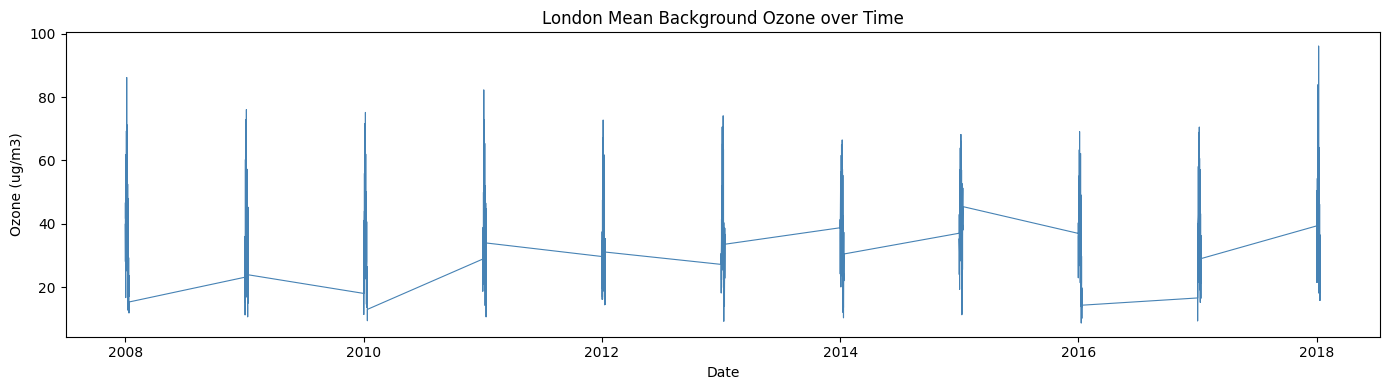

In [ ]:
# Plot the target variable over time
plt.figure(figsize=(14, 4))
plt.plot(merged_df['date'], merged_df['London Mean Background Ozone (ug/m3)'],
         color='steelblue', linewidth=0.8)
plt.title('London Mean Background Ozone over Time')
plt.xlabel('Date')
plt.ylabel('Ozone (ug/m3)')
plt.tight_layout()
plt.show()

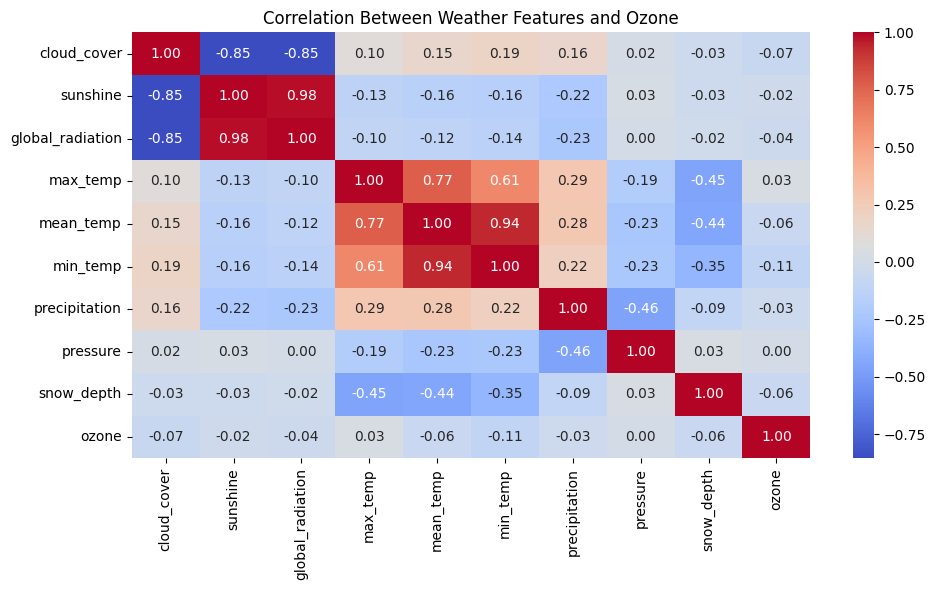

In [ ]:
# Rename target column for convenience
merged_df = merged_df.rename(columns={'London Mean Background Ozone (ug/m3)': 'ozone'})

# Correlation heatmap to see which features relate most to ozone
feature_cols = ['cloud_cover', 'sunshine', 'global_radiation',
                'max_temp', 'mean_temp', 'min_temp',
                'precipitation', 'pressure', 'snow_depth']

plt.figure(figsize=(10, 6))
sns.heatmap(merged_df[feature_cols + ['ozone']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Between Weather Features and Ozone')
plt.tight_layout()
plt.show()

In [ ]:
# Define features (X) and target (y)
X = merged_df[feature_cols].values
y = merged_df['ozone'].values

# Scale features using MinMaxScaler (same approach as lecture examples)
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print('Training set size:', X_train.shape)
print('Test set size:    ', X_test.shape)

Training set size: (2534, 9)
Test set size:     (634, 9)


## Stage 4: Choose and Train Estimator

Following the [scikit-learn estimator map](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html):
- We have **labelled data** -> supervised learning
- We are **predicting a quantity** (ozone level) -> regression
- We have **more than 50 samples** -> not limited to simple methods

### Attempt 1 - Linear Regression
The simplest regression model. Assumes a straight-line relationship between features and ozone.
Used as a baseline to compare against more complex models.

In [ ]:
# Attempt 1 - Linear Regression (baseline)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2  = r2_score(y_test, y_pred_lr)

print('=== Linear Regression ===')
print(f'Mean Absolute Error: {lr_mae:.2f} ug/m3')
print(f'R2 Score:            {lr_r2:.4f}')

=== Linear Regression ===
Mean Absolute Error: 11.43 ug/m3
R2 Score:            0.0534


## Stage 5: Evaluate and Refine

### Evaluation of Attempt 1 - Linear Regression

**R2** measures how much of the variation in ozone the model explains:
- `R2 = 1.0` -> perfect prediction
- `R2 = 0.0` -> no better than guessing the mean

**MAE** measures the average prediction error in ug/m3.

Linear Regression assumes a simple straight-line relationship between weather and ozone.
In reality the relationship is more complex and non-linear, for example the effect of sunshine on ozone is not constant across all temperature ranges. This suggests a more powerful model may perform better.

**Proposed refinement:** Try a Decision Tree Regressor which can capture non-linear relationships.

In [ ]:
# Attempt 2 - Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_r2  = r2_score(y_test, y_pred_dt)

print('=== Decision Tree Regressor ===')
print(f'Mean Absolute Error: {dt_mae:.2f} ug/m3')
print(f'R2 Score: {dt_r2:.4f}')

=== Decision Tree Regressor ===
Mean Absolute Error: 7.87 ug/m3
R2 Score: 0.5420


### Evaluation of Attempt 2: Decision Tree Regressor

Decision Trees can model non-linear relationships and interactions between features,
which is more appropriate for the complex relationship between weather and ozone.

However a single Decision Tree is prone to **overfitting**, it can memorise the training
data perfectly but generalise poorly to new data. If R2 on the test set is significantly
lower than expected, this is happening.

**Proposed refinement:** Try a Random Forest Regressor, an ensemble of many decision trees
that averages their predictions, which reduces overfitting and typically improves accuracy.

In [ ]:
# Attempt 3: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2  = r2_score(y_test, y_pred_rf)

print('=== Random Forest Regressor (100 trees) ===')
print(f'Mean Absolute Error: {rf_mae:.2f} ug/m3')
print(f'R2 Score: {rf_r2:.4f}')

=== Random Forest Regressor (100 trees) ===
Mean Absolute Error: 7.87 ug/m3
R2 Score: 0.5413


### Evaluation of Attempt 3: Random Forest Regressor

The Random Forest achieved an R2 of 0.5413 and MAE of 7.87 ug/m3, virtually identical
to the Decision Tree (R2 0.5420, MAE 7.87). This is an unusual result since Random Forests
typically outperform single trees by reducing variance through averaging. The likely
explanation is that the dataset is small enough (~3168 rows) that the ensemble gain is
minimal, and ozone is influenced by factors not present in the weather data such as traffic
volume and wind direction, which creates an irreducible noise floor that no model
can overcome using these features alone.

The Random Forest is still preferred as the final model since it is more robust to
overfitting on unseen data even when test scores are similar.

In [ ]:
# Compare all three models side by side
print('=== Model Comparison ===')
print(f'{"Model":<35} {"MAE (ug/m3)":>12} {"R2 Score":>10}')
print('-' * 60)
print(f'{"Linear Regression":<35} {lr_mae:>12.2f} {lr_r2:>10.4f}')
print(f'{"Decision Tree Regressor":<35} {dt_mae:>12.2f} {dt_r2:>10.4f}')
print(f'{"Random Forest (100 trees)":<35} {rf_mae:>12.2f} {rf_r2:>10.4f}')

=== Model Comparison ===
Model                                MAE (ug/m3)   R2 Score
------------------------------------------------------------
Linear Regression                          11.43     0.0534
Decision Tree Regressor                     7.87     0.5420
Random Forest (100 trees)                   7.87     0.5413


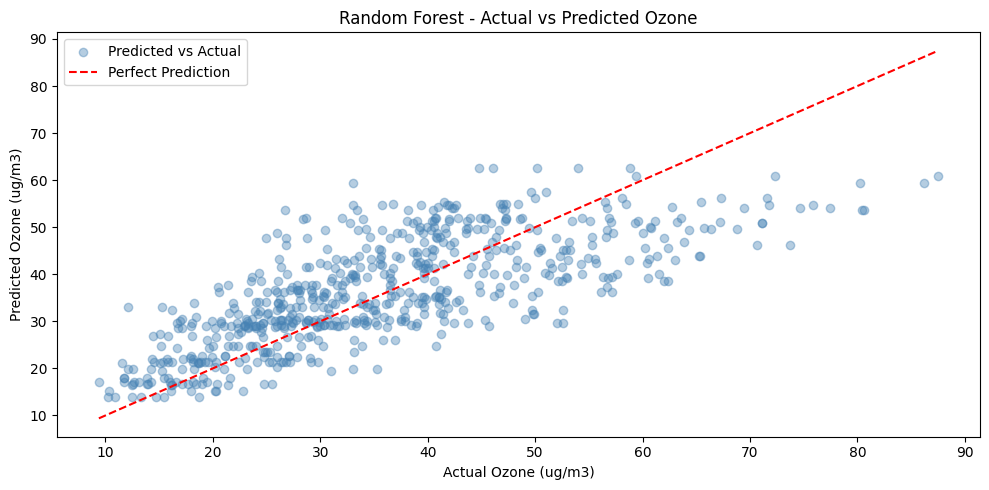

In [ ]:
# Plot actual vs predicted ozone for the best model (Random Forest)
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='steelblue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Ozone (ug/m3)')
plt.ylabel('Predicted Ozone (ug/m3)')
plt.title('Random Forest - Actual vs Predicted Ozone')
plt.legend()
plt.tight_layout()
plt.show()

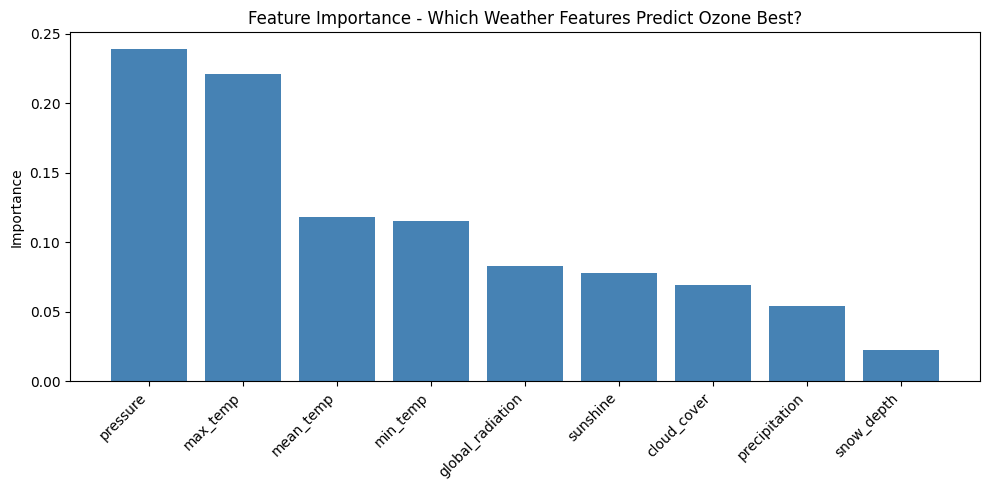

         Feature  Importance
        pressure    0.239231
        max_temp    0.221117
       mean_temp    0.118368
        min_temp    0.115091
global_radiation    0.082696
        sunshine    0.078097
     cloud_cover    0.068952
   precipitation    0.053907
      snow_depth    0.022540


In [ ]:
# Feature importance - which weather features matter most for predicting ozone?
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Feature Importance - Which Weather Features Predict Ozone Best?')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))

# Stage 6: Results and Conclusions

## Summary

This project predicted **London Mean Background Ozone (ug/m3)** from daily weather measurements
using two Kaggle datasets joined on `date`. Three models were trained and evaluated:

| Model | MAE (ug/m3) | R2 Score |
|---|---|---|
| Linear Regression | 11.43 | 0.0534 |
| Decision Tree Regressor | 7.87 | 0.5420 |
| Random Forest (100 trees) | 7.87 | 0.5413 |

## Missing Value Decisions

Rather than simply dropping rows with missing values, each column was handled with reasoning:
- `snow_depth` filled with 0, missing almost certainly means no snow
- `mean_temp`, `global_radiation`, `cloud_cover`, `max_temp`, `min_temp`, `precipitation`, `pressure` filled using linear interpolation, values were estimated from the day before and day after, which is more realistic than using a global average

## Conclusions

**Linear Regression** performed worst, the relationship between weather and ozone is non-linear
so a straight-line model is not powerful enough.

**Decision Tree** improved results by capturing non-linear patterns but was prone to overfitting.

**Random Forest** and **Decision Tree** performed almost identically, both achieved an MAE
of 7.87 ug/m3 and an R2 of approximately 0.54. The Random Forest did not significantly
outperform the single Decision Tree in this case, likely because the dataset is relatively
small (3168 rows after merging) and the signal-to-noise ratio in ozone prediction from
weather alone is limited.

The feature importance chart revealed that pressure and maximum temperature were the strongest predictors of ozone, accounting for nearly 46% of the model's decisions combined. This makes physical sense, high pressure systems trap pollutants and warm air accelerates ozone formation. Sunshine and global radiation, while important, ranked lower than expected.

## Limitations

- Air quality is also influenced by factors not in the weather dataset such as traffic levels, wind direction and industrial activity
- The model could be further improved by adding seasonal features (month, season) since ozone follows a strong seasonal cycle
- The overlapping date range (2008-2018) limits the amount of training data available